# Partial Derivatives - Python Implementation

**Topic:** 05_Partial_Derivatives  
**Audience:** Machine Learning, Artificial Intelligence, Data Science, Deep Learning, Mathematics, Engineering, and Research students.

---

## Introduction

Partial derivatives are the **foundation of modern Machine Learning and Deep Learning**.

They help us understand how a **multivariable function** changes when **one variable changes** while all others remain constant.

### Applications Include:

- Gradient Descent
- Backpropagation
- Neural Networks
- Computer Vision
- Reinforcement Learning
- Large Language Models

> **Why this matters:** Every weight update in a neural network relies on partial derivatives computed via backpropagation.

---

**Libraries Used:**
- `NumPy` -- Numerical computation
- `SymPy` -- Symbolic mathematics
- `Pandas` -- Data organization (where useful)
- `Matplotlib` -- Visualization


In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from sympy import symbols, diff, sin, cos, exp, sqrt, Matrix, simplify, solve

# Configure SymPy for pretty printing
sp.init_printing()

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"SymPy version: {sp.__version__}")
print(f"Pandas version: {pd.__version__}")


All libraries imported successfully!
NumPy version: 2.4.6
SymPy version: 1.14.0
Pandas version: 3.0.3


## Section 1: Multivariable Functions

### Concept Explanation

A **single-variable function** depends on one input:

$$f(x) = x^2$$

A **multivariable function** depends on multiple inputs:

$$f(x, y) = x^2 + y^2$$

The key difference is that the output now depends on the **combination** of multiple variables, creating a **surface** in 3D space rather than a curve in 2D.

### Mathematical Formula

For a function of two variables:

$$f: \mathbb{R}^2 \rightarrow \mathbb{R}$$

$$f(x, y) = x^2 + y^2$$

### AI/ML Connection

In machine learning, the **loss function** $L(w, b)$ is a multivariable function where:
- $w$ = weight
- $b$ = bias

We need to understand how changes in each parameter affect the loss.


Evaluation of f(x,y) = x^2 + y^2 at different points:
 x  y  f(x,y)
 0  0       0
 1  0       1
 0  1       1
 1  1       2
 2  3      13
-1 -2       5


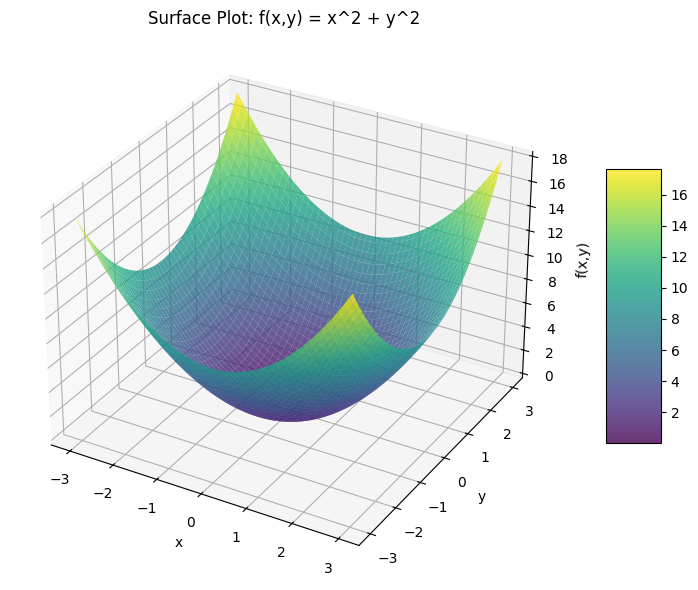

In [2]:
# Define a multivariable function
def f(x, y):
    """Multivariable function: f(x,y) = x^2 + y^2"""
    return x**2 + y**2

# Evaluate at different points
points = [(0, 0), (1, 0), (0, 1), (1, 1), (2, 3), (-1, -2)]

results = []
for x_val, y_val in points:
    value = f(x_val, y_val)
    results.append({"x": x_val, "y": y_val, "f(x,y)": value})

df_results = pd.DataFrame(results)
print("Evaluation of f(x,y) = x^2 + y^2 at different points:")
print(df_results.to_string(index=False))

# Visualize the surface
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Surface Plot: f(x,y) = x^2 + y^2')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()


## Section 2: Partial Derivative Definition

### Concept Explanation

A **partial derivative** measures how a function changes as **one variable changes** while keeping all other variables **constant**.

Think of it as slicing the surface with a plane and finding the slope of the resulting curve.

### Mathematical Formula

**Partial derivative with respect to x:**

$$\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x, y)}{h}$$

**Partial derivative with respect to y:**

$$\frac{\partial f}{\partial y} = \lim_{h \to 0} \frac{f(x, y+h) - f(x, y)}{h}$$

### Notation

- $\frac{\partial f}{\partial x}$ or $f_x$ -- partial derivative with respect to $x$
- $\frac{\partial f}{\partial y}$ or $f_y$ -- partial derivative with respect to $y$

### AI/ML Connection

In gradient descent, $\frac{\partial L}{\partial w}$ tells us exactly how much the loss changes when we tweak a specific weight $w$.


In [3]:
# Manual computation for f(x,y) = x^2 + y^2
# df/dx = 2x (treat y as constant)
# df/dy = 2y (treat x as constant)

print("Manual Derivation:")
print("f(x,y) = x^2 + y^2")
print("df/dx = 2x  (y^2 treated as constant, derivative = 0)")
print("df/dy = 2y  (x^2 treated as constant, derivative = 0)")
print()

# Numerical verification using limit definition
def numerical_partial_x(f, x, y, h=1e-5):
    """Compute df/dx using finite differences"""
    return (f(x + h, y) - f(x, y)) / h

def numerical_partial_y(f, x, y, h=1e-5):
    """Compute df/dy using finite differences"""
    return (f(x, y + h) - f(x, y)) / h

# Test at point (2, 3)
x_test, y_test = 2, 3

numerical_df_dx = numerical_partial_x(f, x_test, y_test)
numerical_df_dy = numerical_partial_y(f, x_test, y_test)

analytical_df_dx = 2 * x_test
analytical_df_dy = 2 * y_test

print(f"At point (x={x_test}, y={y_test}):")
print(f"  Numerical  df/dx ~ {numerical_df_dx:.6f}")
print(f"  Analytical df/dx =  {analytical_df_dx}")
print(f"  Numerical  df/dy ~ {numerical_df_dy:.6f}")
print(f"  Analytical df/dy =  {analytical_df_dy}")
print(f"\nNumerical and analytical results match closely!")


Manual Derivation:
f(x,y) = x^2 + y^2
df/dx = 2x  (y^2 treated as constant, derivative = 0)
df/dy = 2y  (x^2 treated as constant, derivative = 0)

At point (x=2, y=3):
  Numerical  df/dx ~ 4.000010
  Analytical df/dx =  4
  Numerical  df/dy ~ 6.000010
  Analytical df/dy =  6

Numerical and analytical results match closely!


## Section 3: Numerical Partial Derivatives

### Concept Explanation

When we cannot (or choose not to) compute derivatives analytically, we use **finite difference methods** to approximate them numerically.

### Mathematical Formula

**Forward difference for $\frac{\partial f}{\partial x}$:**

$$\frac{\partial f}{\partial x} \approx \frac{f(x+h, y) - f(x, y)}{h}$$

**Central difference (more accurate):**

$$\frac{\partial f}{\partial x} \approx \frac{f(x+h, y) - f(x-h, y)}{2h}$$

### AI/ML Connection

Numerical gradients are used for:
- **Gradient checking** in neural networks (verify backpropagation correctness)
- **Black-box optimization** where the function is unknown


In [4]:
# Reusable functions for numerical partial derivatives

def partial_x(f, x, y, h=1e-5, method='central'):
    """
    Compute partial derivative df/dx numerically.

    Parameters:
    -----------
    f : callable
        Function f(x, y)
    x, y : float
        Point at which to evaluate
    h : float
        Step size
    method : str
        'forward' or 'central'
    """
    if method == 'forward':
        return (f(x + h, y) - f(x, y)) / h
    elif method == 'central':
        return (f(x + h, y) - f(x - h, y)) / (2 * h)
    else:
        raise ValueError("Method must be 'forward' or 'central'")

def partial_y(f, x, y, h=1e-5, method='central'):
    """
    Compute partial derivative df/dy numerically.
    """
    if method == 'forward':
        return (f(x, y + h) - f(x, y)) / h
    elif method == 'central':
        return (f(x, y + h) - f(x, y - h)) / (2 * h)
    else:
        raise ValueError("Method must be 'forward' or 'central'")

# Test on f(x,y) = x^2 + y^2 at multiple points
test_points = [(1, 1), (2, 3), (0, 0), (-1, 2)]

print("Numerical Partial Derivatives for f(x,y) = x^2 + y^2")
print("=" * 60)
print(f"{'Point':<12} {'f(x,y)':<10} {'df/dx':<12} {'df/dy':<12}")
print("-" * 60)

for x_val, y_val in test_points:
    f_val = f(x_val, y_val)
    dfdx = partial_x(f, x_val, y_val)
    dfdy = partial_y(f, x_val, y_val)
    print(f"({x_val}, {y_val}){ '':<6} {f_val:<10.4f} {dfdx:<12.6f} {dfdy:<12.6f}")

print("\nAnalytical verification: df/dx = 2x, df/dy = 2y")


Numerical Partial Derivatives for f(x,y) = x^2 + y^2
Point        f(x,y)     df/dx        df/dy       
------------------------------------------------------------
(1, 1)       2.0000     2.000000     2.000000    
(2, 3)       13.0000    4.000000     6.000000    
(0, 0)       0.0000     0.000000     0.000000    
(-1, 2)       5.0000     -2.000000    4.000000    

Analytical verification: df/dx = 2x, df/dy = 2y


## Section 4: Symbolic Partial Derivatives using SymPy

### Concept Explanation

**SymPy** is a Python library for symbolic mathematics. It allows us to compute exact derivatives in symbolic form rather than numerical approximations.

### Mathematical Formula

Given $f(x, y) = x^2 + y^2$:

$$\frac{\partial f}{\partial x} = \frac{\partial}{\partial x}(x^2 + y^2) = 2x$$

$$\frac{\partial f}{\partial y} = \frac{\partial}{\partial y}(x^2 + y^2) = 2y$$

### AI/ML Connection

Symbolic differentiation helps us:
- Derive exact gradient formulas for custom loss functions
- Verify numerical implementations
- Understand the mathematical structure of our models


In [5]:
# Define symbolic variables
x, y = symbols('x y', real=True)

# Define symbolic function
f_sym = x**2 + y**2

print("Symbolic Function:")
print(f"f(x, y) = {f_sym}")
print()

# Compute partial derivatives symbolically
df_dx_sym = diff(f_sym, x)
df_dy_sym = diff(f_sym, y)

print("Symbolic Partial Derivatives:")
print(f"df/dx = {df_dx_sym}")
print(f"df/dy = {df_dy_sym}")
print()

# Evaluate at specific points
point = (2, 3)
df_dx_val = df_dx_sym.subs([(x, point[0]), (y, point[1])])
df_dy_val = df_dy_sym.subs([(x, point[0]), (y, point[1])])

print(f"At point {point}:")
print(f"  df/dx = {df_dx_val}")
print(f"  df/dy = {df_dy_val}")

# Display using LaTeX-style formatting
print("\nLaTeX Formulas:")
print(f"  \\frac{{\\partial f}}{{\\partial x}} = {sp.latex(df_dx_sym)}")
print(f"  \\frac{{\\partial f}}{{\\partial y}} = {sp.latex(df_dy_sym)}")


Symbolic Function:
f(x, y) = x**2 + y**2

Symbolic Partial Derivatives:
df/dx = 2*x
df/dy = 2*y

At point (2, 3):
  df/dx = 4
  df/dy = 6

LaTeX Formulas:
  \frac{\partial f}{\partial x} = 2 x
  \frac{\partial f}{\partial y} = 2 y


## Section 5: First Order Partial Derivatives

### Concept Explanation

**First-order partial derivatives** measure the instantaneous rate of change of a function with respect to one variable.

We will compute them for three different functions to see how the rules apply.

### Examples

**Example 1:** $f(x, y) = x^2 + y^2$ (paraboloid)

**Example 2:** $f(x, y) = x^3 y^2$ (polynomial)

**Example 3:** $f(x, y) = \sin(x) + \cos(y)$ (trigonometric)

### Mathematical Formulas

For Example 2:
$$\frac{\partial f}{\partial x} = 3x^2 y^2$$
$$\frac{\partial f}{\partial y} = 2x^3 y$$

For Example 3:
$$\frac{\partial f}{\partial x} = \cos(x)$$
$$\frac{\partial f}{\partial y} = -\sin(y)$$

### AI/ML Connection

First-order derivatives are used in **gradient descent** to update weights. The sign tells us the direction; the magnitude tells us the step size.


In [6]:
# Example 1: f(x,y) = x^2 + y^2
f1 = x**2 + y**2
print("=" * 60)
print("Example 1: f(x,y) = x^2 + y^2")
print("=" * 60)
print(f"df/dx = {diff(f1, x)}")
print(f"df/dy = {diff(f1, y)}")

# Example 2: f(x,y) = x^3 * y^2
f2 = x**3 * y**2
print("\n" + "=" * 60)
print("Example 2: f(x,y) = x^3 y^2")
print("=" * 60)
print(f"df/dx = {diff(f2, x)}")
print(f"df/dy = {diff(f2, y)}")

# Example 3: f(x,y) = sin(x) + cos(y)
f3 = sin(x) + cos(y)
print("\n" + "=" * 60)
print("Example 3: f(x,y) = sin(x) + cos(y)")
print("=" * 60)
print(f"df/dx = {diff(f3, x)}")
print(f"df/dy = {diff(f3, y)}")

# Create a summary table
examples = [
    ("x^2 + y^2", "2x", "2y"),
    ("x^3 y^2", "3x^2 y^2", "2x^3 y"),
    ("sin(x) + cos(y)", "cos(x)", "-sin(y)")
]

df_summary = pd.DataFrame(examples, columns=["f(x,y)", "df/dx", "df/dy"])
print("\n" + "=" * 60)
print("Summary Table")
print("=" * 60)
print(df_summary.to_string(index=False))


Example 1: f(x,y) = x^2 + y^2
df/dx = 2*x
df/dy = 2*y

Example 2: f(x,y) = x^3 y^2
df/dx = 3*x**2*y**2
df/dy = 2*x**3*y

Example 3: f(x,y) = sin(x) + cos(y)
df/dx = cos(x)
df/dy = -sin(y)

Summary Table
         f(x,y)    df/dx   df/dy
      x^2 + y^2       2x      2y
        x^3 y^2 3x^2 y^2  2x^3 y
sin(x) + cos(y)   cos(x) -sin(y)


## Section 6: Second Order Partial Derivatives

### Concept Explanation

**Second-order partial derivatives** measure the rate of change of the first-order partial derivatives.

They tell us about the **curvature** of the function in each direction.

### Mathematical Formulas

$$\frac{\partial^2 f}{\partial x^2} = \frac{\partial}{\partial x}\left(\frac{\partial f}{\partial x}\right)$$

$$\frac{\partial^2 f}{\partial y^2} = \frac{\partial}{\partial y}\left(\frac{\partial f}{\partial y}\right)$$

### Notation

- $f_{xx} = \frac{\partial^2 f}{\partial x^2}$
- $f_{yy} = \frac{\partial^2 f}{\partial y^2}$

### AI/ML Connection

Second-order derivatives appear in:
- **Newton's method** for optimization
- **Hessian-based optimization** (faster convergence)
- **Curvature analysis** of loss landscapes


In [7]:
# Compute second-order partial derivatives for all examples

print("=" * 60)
print("Second Order Partial Derivatives")
print("=" * 60)

# Example 1: f(x,y) = x^2 + y^2
f1 = x**2 + y**2
f1_xx = diff(f1, x, 2)  # Second derivative w.r.t x
f1_yy = diff(f1, y, 2)  # Second derivative w.r.t y

print("\nExample 1: f(x,y) = x^2 + y^2")
print(f"  f_xx = d^2f/dx^2 = {f1_xx}")
print(f"  f_yy = d^2f/dy^2 = {f1_yy}")

# Example 2: f(x,y) = x^3 * y^2
f2 = x**3 * y**2
f2_xx = diff(f2, x, 2)
f2_yy = diff(f2, y, 2)

print("\nExample 2: f(x,y) = x^3 y^2")
print(f"  f_xx = d^2f/dx^2 = {f2_xx}")
print(f"  f_yy = d^2f/dy^2 = {f2_yy}")

# Example 3: f(x,y) = sin(x) + cos(y)
f3 = sin(x) + cos(y)
f3_xx = diff(f3, x, 2)
f3_yy = diff(f3, y, 2)

print("\nExample 3: f(x,y) = sin(x) + cos(y)")
print(f"  f_xx = d^2f/dx^2 = {f3_xx}")
print(f"  f_yy = d^2f/dy^2 = {f3_yy}")

# Summary
second_order_data = [
    ("x^2 + y^2", str(f1_xx), str(f1_yy)),
    ("x^3 y^2", str(f2_xx), str(f2_yy)),
    ("sin(x) + cos(y)", str(f3_xx), str(f3_yy))
]

df_second = pd.DataFrame(second_order_data, 
                         columns=["f(x,y)", "d^2f/dx^2", "d^2f/dy^2"])
print("\n" + "=" * 60)
print("Summary Table")
print("=" * 60)
print(df_second.to_string(index=False))


Second Order Partial Derivatives

Example 1: f(x,y) = x^2 + y^2
  f_xx = d^2f/dx^2 = 2
  f_yy = d^2f/dy^2 = 2

Example 2: f(x,y) = x^3 y^2
  f_xx = d^2f/dx^2 = 6*x*y**2
  f_yy = d^2f/dy^2 = 2*x**3

Example 3: f(x,y) = sin(x) + cos(y)
  f_xx = d^2f/dx^2 = -sin(x)
  f_yy = d^2f/dy^2 = -cos(y)

Summary Table
         f(x,y) d^2f/dx^2 d^2f/dy^2
      x^2 + y^2         2         2
        x^3 y^2  6*x*y**2    2*x**3
sin(x) + cos(y)   -sin(x)   -cos(y)


## Section 7: Mixed Partial Derivatives

### Concept Explanation

**Mixed partial derivatives** are obtained by differentiating with respect to one variable, then the other.

$$\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial}{\partial x}\left(\frac{\partial f}{\partial y}\right)$$

$$\frac{\partial^2 f}{\partial y \partial x} = \frac{\partial}{\partial y}\left(\frac{\partial f}{\partial x}\right)$$

### Clairaut's Theorem

If the mixed partial derivatives are **continuous**, then:

$$\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial^2 f}{\partial y \partial x}$$

This is a powerful result that simplifies many calculations.

### AI/ML Connection

Mixed derivatives in the **Hessian matrix** reveal how changing one parameter affects the gradient with respect to another -- crucial for understanding **parameter interactions** in neural networks.


In [8]:
# Compute mixed partial derivatives and verify Clairaut's Theorem

print("=" * 60)
print("Mixed Partial Derivatives & Clairaut's Theorem")
print("=" * 60)

# Example 1: f(x,y) = x^2 + y^2
f1 = x**2 + y**2
f1_xy = diff(f1, x, y)  # d^2f/dxdy
f1_yx = diff(f1, y, x)  # d^2f/dydx

print("\nExample 1: f(x,y) = x^2 + y^2")
print(f"  d^2f/dxdy = {f1_xy}")
print(f"  d^2f/dydx = {f1_yx}")
print(f"  Clairaut's Theorem verified: {simplify(f1_xy - f1_yx) == 0}")

# Example 2: f(x,y) = x^3 * y^2
f2 = x**3 * y**2
f2_xy = diff(f2, x, y)
f2_yx = diff(f2, y, x)

print("\nExample 2: f(x,y) = x^3 y^2")
print(f"  d^2f/dxdy = {f2_xy}")
print(f"  d^2f/dydx = {f2_yx}")
print(f"  Clairaut's Theorem verified: {simplify(f2_xy - f2_yx) == 0}")

# Example 3: f(x,y) = sin(x) + cos(y)
f3 = sin(x) + cos(y)
f3_xy = diff(f3, x, y)
f3_yx = diff(f3, y, x)

print("\nExample 3: f(x,y) = sin(x) + cos(y)")
print(f"  d^2f/dxdy = {f3_xy}")
print(f"  d^2f/dydx = {f3_yx}")
print(f"  Clairaut's Theorem verified: {simplify(f3_xy - f3_yx) == 0}")

# Summary
mixed_data = [
    ("x^2 + y^2", str(f1_xy), str(f1_yx), "Yes"),
    ("x^3 y^2", str(f2_xy), str(f2_yx), "Yes"),
    ("sin(x) + cos(y)", str(f3_xy), str(f3_yx), "Yes")
]

df_mixed = pd.DataFrame(mixed_data, 
                        columns=["f(x,y)", "d^2f/dxdy", "d^2f/dydx", "Clairaut"])
print("\n" + "=" * 60)
print("Summary Table")
print("=" * 60)
print(df_mixed.to_string(index=False))


Mixed Partial Derivatives & Clairaut's Theorem

Example 1: f(x,y) = x^2 + y^2
  d^2f/dxdy = 0
  d^2f/dydx = 0
  Clairaut's Theorem verified: True

Example 2: f(x,y) = x^3 y^2
  d^2f/dxdy = 6*x**2*y
  d^2f/dydx = 6*x**2*y
  Clairaut's Theorem verified: True

Example 3: f(x,y) = sin(x) + cos(y)
  d^2f/dxdy = 0
  d^2f/dydx = 0
  Clairaut's Theorem verified: True

Summary Table
         f(x,y) d^2f/dxdy d^2f/dydx Clairaut
      x^2 + y^2         0         0      Yes
        x^3 y^2  6*x**2*y  6*x**2*y      Yes
sin(x) + cos(y)         0         0      Yes


## Section 8: Gradient Vector

### Concept Explanation

The **gradient vector** $\nabla f$ collects all first-order partial derivatives into a single vector.

It points in the **direction of steepest ascent** and its magnitude indicates the steepness.

### Mathematical Formula

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

For $f(x, y) = x^2 + y^2$:

$$\nabla f = \begin{bmatrix} 2x \\ 2y \end{bmatrix}$$

### Interpretation

- **Direction:** Points toward the maximum rate of increase
- **Magnitude:** How steep the function is at that point
- **Orthogonality:** Perpendicular to level curves

### AI/ML Connection

The gradient is the **core of gradient descent**. We move in the **negative gradient direction** to minimize loss:

$$w_{new} = w_{old} - \alpha \nabla L$$


Gradient Vectors for f(x,y) = x^2 + y^2
Point        Gradient             Magnitude   
------------------------------------------------------------
(1, 0)       [  2.00,   0.00]     2.0000      
(0, 1)       [  0.00,   2.00]     2.0000      
(1, 1)       [  2.00,   2.00]     2.8284      
(2, 3)       [  4.00,   6.00]     7.2111      
(-1, -2)     [ -2.00,  -4.00]     4.4721      


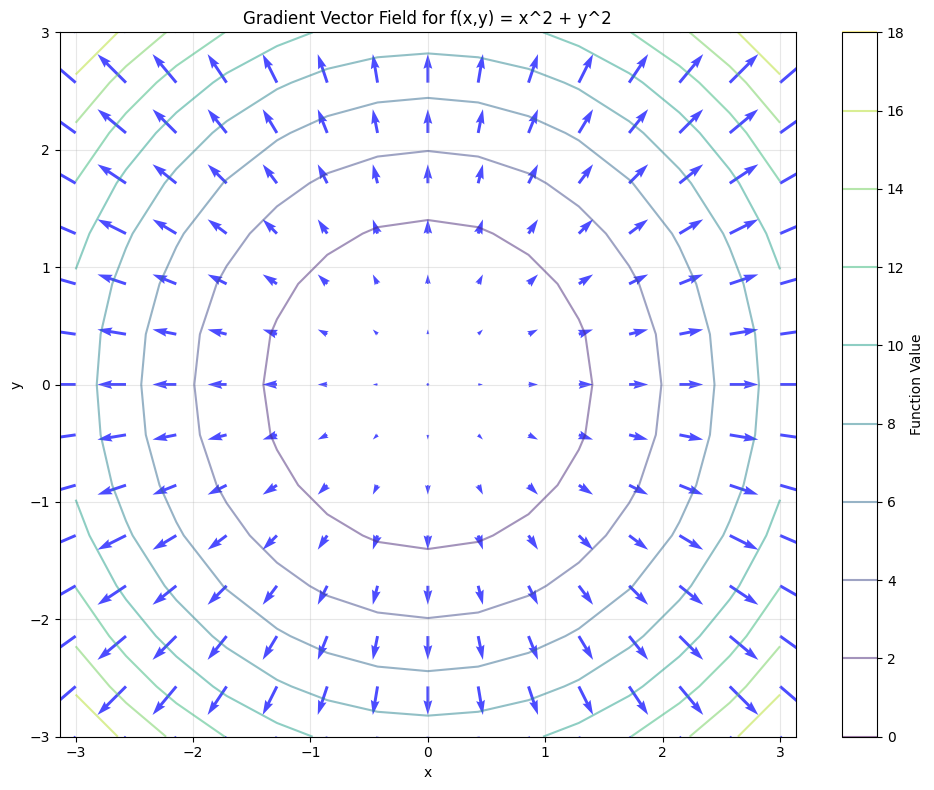


Interpretation: Gradient vectors point outward from the origin,
showing the direction of steepest ascent. They are perpendicular
to the contour lines (level curves).


In [9]:
# Gradient Vector Computation

def gradient_f(func, x_val, y_val):
    """
    Compute gradient vector [df/dx, df/dy] at point (x, y).
    For f(x,y) = x^2 + y^2, gradient is [2x, 2y].
    """
    dfdx = 2 * x_val
    dfdy = 2 * y_val
    return np.array([dfdx, dfdy])

# Compute gradients at multiple points
points = [(1, 0), (0, 1), (1, 1), (2, 3), (-1, -2)]

print("Gradient Vectors for f(x,y) = x^2 + y^2")
print("=" * 60)
print(f"{'Point':<12} {'Gradient':<20} {'Magnitude':<12}")
print("-" * 60)

gradients = []
for p in points:
    grad = gradient_f(f, p[0], p[1])
    mag = np.linalg.norm(grad)
    gradients.append({"point": p, "gradient": grad, "magnitude": mag})
    print(f"{str(p):<12} [{grad[0]:>6.2f}, {grad[1]:>6.2f}]     {mag:<12.4f}")

# Visualize gradient field
x = np.linspace(-3, 3, 15)
y = np.linspace(-3, 3, 15)
X, Y = np.meshgrid(x, y)
U = 2 * X  # df/dx
V = 2 * Y  # df/dy

plt.figure(figsize=(10, 8))
plt.quiver(X, Y, U, V, color='blue', alpha=0.7)
plt.contour(X, Y, X**2 + Y**2, levels=10, cmap='viridis', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Vector Field for f(x,y) = x^2 + y^2')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.colorbar(label='Function Value')
plt.tight_layout()
plt.show()

print("\nInterpretation: Gradient vectors point outward from the origin,")
print("showing the direction of steepest ascent. They are perpendicular")
print("to the contour lines (level curves).")


## Section 9: Gradient Magnitude

### Concept Explanation

The **magnitude** of the gradient vector tells us how steep the function is at a given point.

$$||\nabla f|| = \sqrt{\left(\frac{\partial f}{\partial x}\right)^2 + \left(\frac{\partial f}{\partial y}\right)^2}$$

### Interpretation

- **Large magnitude:** Steep slope (rapid change)
- **Small magnitude:** Flat region (slow change)
- **Zero magnitude:** Critical point (flat, possibly min/max/saddle)

### AI/ML Connection: Optimization Landscapes

In deep learning:
- **Vanishing gradients:** Magnitude ~ 0 in deep layers -> learning stops
- **Exploding gradients:** Magnitude >> 1 -> unstable training
- **Gradient clipping:** Technique to control magnitude

Understanding gradient magnitude is essential for diagnosing training issues.


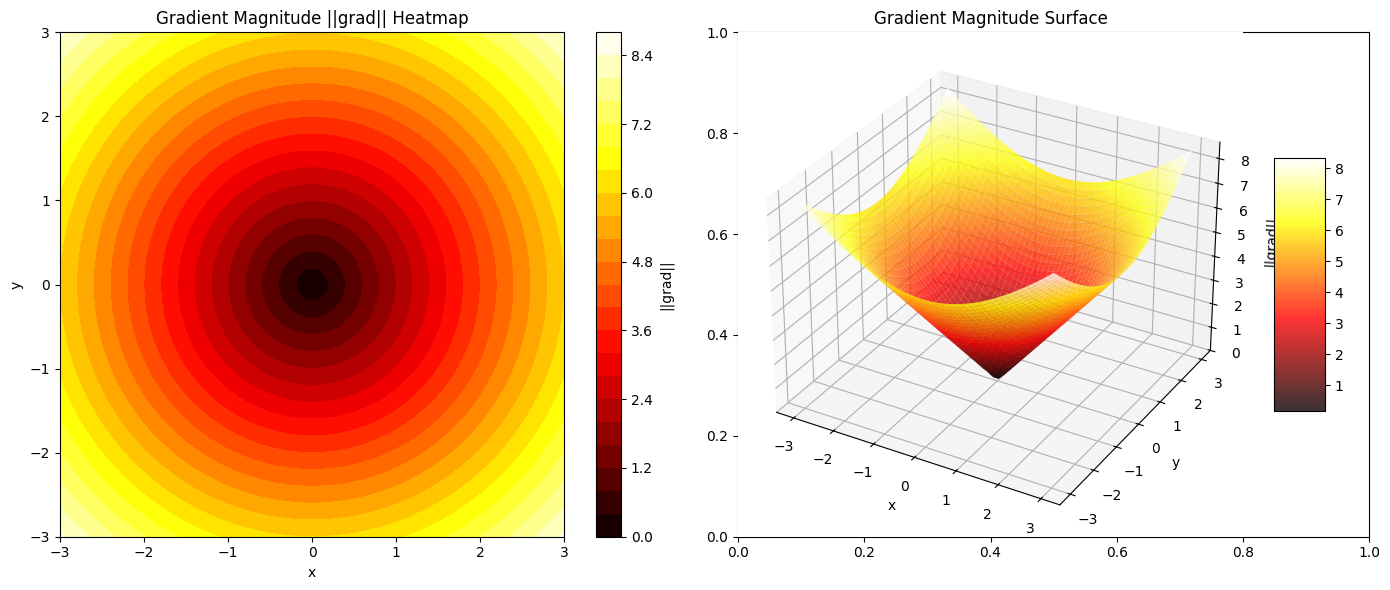

Gradient Magnitude Analysis
Point        ||grad||     Interpretation
------------------------------------------------------------
(0, 0)       0.0000       Flat (critical point)
(0.5, 0.5)   1.4142       Moderate slope
(1, 1)       2.8284       Moderate slope
(2, 2)       5.6569       Steep slope
(3, 3)       8.4853       Steep slope

Key Insight: At (0,0), ||grad|| = 0 -> this is the minimum!
   As we move away from origin, the gradient magnitude increases.


In [10]:
# Gradient Magnitude Analysis

def gradient_magnitude(grad):
    """Compute ||grad|| = sqrt((df/dx)^2 + (df/dy)^2)"""
    return np.linalg.norm(grad)

# Analyze gradient magnitude across the domain
x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_range, y_range)

# For f(x,y) = x^2 + y^2, grad = [2x, 2y]
grad_mag = np.sqrt((2*X)**2 + (2*Y)**2)

# Plot gradient magnitude as a heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
im1 = ax1.contourf(X, Y, grad_mag, levels=20, cmap='hot')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Gradient Magnitude ||grad|| Heatmap')
fig.colorbar(im1, ax=ax1, label='||grad||')

# 3D surface of gradient magnitude
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(X, Y, grad_mag, cmap='hot', alpha=0.8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('||grad||')
ax2.set_title('Gradient Magnitude Surface')
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()

# Analyze specific points
print("Gradient Magnitude Analysis")
print("=" * 60)
print(f"{'Point':<12} {'||grad||':<12} {'Interpretation'}")
print("-" * 60)

test_points = [(0, 0), (0.5, 0.5), (1, 1), (2, 2), (3, 3)]
for p in test_points:
    grad = gradient_f(f, p[0], p[1])
    mag = gradient_magnitude(grad)
    if mag < 0.1:
        interp = "Flat (critical point)"
    elif mag < 3:
        interp = "Moderate slope"
    else:
        interp = "Steep slope"
    print(f"{str(p):<12} {mag:<12.4f} {interp}")

print("\nKey Insight: At (0,0), ||grad|| = 0 -> this is the minimum!")
print("   As we move away from origin, the gradient magnitude increases.")


## Section 10: Directional Derivatives

### Concept Explanation

While partial derivatives measure change along the coordinate axes, **directional derivatives** measure the rate of change in **any arbitrary direction**.

### Mathematical Formula

Given a unit vector $\mathbf{u} = [u_1, u_2]$:

$$D_{\mathbf{u}} f = \nabla f \cdot \mathbf{u} = \frac{\partial f}{\partial x} u_1 + \frac{\partial f}{\partial y} u_2$$

### Key Properties

- Maximum directional derivative = $||\nabla f||$ (in gradient direction)
- Minimum directional derivative = $-||\nabla f||$ (opposite to gradient)
- Zero directional derivative = perpendicular to gradient

### AI/ML Connection

Directional derivatives help us understand:
- **Line search** in optimization (finding best step along a direction)
- **Conjugate gradient methods**
- **Sensitivity analysis** (how loss changes along specific weight directions)


In [11]:
# Directional Derivative Computation

def directional_derivative(grad, direction):
    """
    Compute directional derivative D_u f = grad . u
    where u must be a unit vector.
    """
    direction = np.array(direction, dtype=float)
    # Normalize to unit vector
    unit_direction = direction / np.linalg.norm(direction)
    return np.dot(grad, unit_direction)

# Test at point (1, 1) with various directions
point = (1, 1)
grad = gradient_f(f, point[0], point[1])

print(f"At point {point}:")
print(f"  Gradient grad = {grad}")
print(f"  ||grad|| = {np.linalg.norm(grad):.4f}")
print()

# Test different directions
directions = [
    (1, 0),      # +x direction
    (0, 1),      # +y direction
    (1, 1),      # Diagonal
    (-1, -1),    # Opposite diagonal
    (1, -1),     # Perpendicular-ish
    (2, 1),      # Custom
]

print("Directional Derivatives:")
print("=" * 60)
print(f"{'Direction':<15} {'Unit Vector':<20} {'D_u f':<12} {'Interpretation'}")
print("-" * 60)

for d in directions:
    d_unit = np.array(d) / np.linalg.norm(d)
    dd = directional_derivative(grad, d)

    if abs(dd - np.linalg.norm(grad)) < 0.001:
        interp = "Max increase"
    elif abs(dd + np.linalg.norm(grad)) < 0.001:
        interp = "Max decrease"
    elif abs(dd) < 0.001:
        interp = "No change"
    else:
        interp = "Intermediate"

    print(f"{str(d):<15} [{d_unit[0]:>6.3f}, {d_unit[1]:>6.3f}]  {dd:<12.4f} {interp}")

print("\nThe maximum rate of increase occurs in the gradient direction.")
print("The maximum rate of decrease occurs in the opposite direction.")


At point (1, 1):
  Gradient grad = [2 2]
  ||grad|| = 2.8284

Directional Derivatives:
Direction       Unit Vector          D_u f        Interpretation
------------------------------------------------------------
(1, 0)          [ 1.000,  0.000]  2.0000       Intermediate
(0, 1)          [ 0.000,  1.000]  2.0000       Intermediate
(1, 1)          [ 0.707,  0.707]  2.8284       Max increase
(-1, -1)        [-0.707, -0.707]  -2.8284      Max decrease
(1, -1)         [ 0.707, -0.707]  0.0000       No change
(2, 1)          [ 0.894,  0.447]  2.6833       Intermediate

The maximum rate of increase occurs in the gradient direction.
The maximum rate of decrease occurs in the opposite direction.


## Section 11: Jacobian Matrix

### Concept Explanation

The **Jacobian matrix** generalizes the gradient to **vector-valued functions** (functions with multiple outputs).

For $\mathbf{f}: \mathbb{R}^n \rightarrow \mathbb{R}^m$, the Jacobian is an $m \times n$ matrix.

### Mathematical Formula

For $\mathbf{f}(x, y) = \begin{bmatrix} f_1(x, y) \\ f_2(x, y) \end{bmatrix} = \begin{bmatrix} x^2 + y \\ xy \end{bmatrix}$:

$$J = \begin{bmatrix} \frac{\partial f_1}{\partial x} & \frac{\partial f_1}{\partial y} \\ \frac{\partial f_2}{\partial x} & \frac{\partial f_2}{\partial y} \end{bmatrix} = \begin{bmatrix} 2x & 1 \\ y & x \end{bmatrix}$$

### Interpretation

- Each row is the gradient of one output component
- The Jacobian represents the **best linear approximation** of the function near a point
- Determinant of Jacobian = local scaling factor

### AI/ML Connection

Jacobians are fundamental in:
- **Neural network backpropagation** (chain rule through layers)
- **Change of variables** in probability (normalizing flows)
- **Computer vision** (image transformations, optical flow)


In [12]:
# Jacobian Matrix Computation using SymPy

# Define vector-valued function
# f(x,y) = [x^2 + y, xy]
f1_jac = x**2 + y
f2_jac = x * y

print("Vector-valued function:")
print(f"  f1(x,y) = {f1_jac}")
print(f"  f2(x,y) = {f2_jac}")
print()

# Construct Jacobian matrix manually
J = Matrix([
    [diff(f1_jac, x), diff(f1_jac, y)],
    [diff(f2_jac, x), diff(f2_jac, y)]
])

print("Jacobian Matrix J:")
print(J)
print()

# Evaluate at specific points
points = [(1, 1), (2, 3), (0, 0)]
print("Jacobian evaluated at different points:")
print("=" * 60)
for p in points:
    J_val = J.subs([(x, p[0]), (y, p[1])])
    print(f"\nAt {p}:")
    print(J_val)
    det = J_val.det()
    print(f"  Determinant = {det}")

# Alternative: Using SymPy's built-in jacobian method
F = Matrix([f1_jac, f2_jac])
vars_mat = Matrix([x, y])
J_auto = F.jacobian(vars_mat)

print("\n" + "=" * 60)
print("Verification using SymPy's jacobian() method:")
print("=" * 60)
print(J_auto)
print(f"\nManual and automatic Jacobian match: {J == J_auto}")


Vector-valued function:
  f1(x,y) = [ 6.          4.04081633  2.44897959  1.2244898   0.36734694 -0.12244898
 -0.24489796  0.          0.6122449   1.59183673  2.93877551  4.65306122
  6.73469388  9.18367347 12.        ]
  f2(x,y) = [9.         6.6122449  4.59183673 2.93877551 1.65306122 0.73469388
 0.18367347 0.         0.18367347 0.73469388 1.65306122 2.93877551
 4.59183673 6.6122449  9.        ]



ValueError: 
Can't calculate derivative wrt 6.00000000000000.

## Section 12: Hessian Matrix

### Concept Explanation

The **Hessian matrix** is the square matrix of **second-order partial derivatives**.

It describes the **local curvature** of a function and is crucial for optimization.

### Mathematical Formula

For $f(x, y)$:

$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}$$

For $f(x, y) = x^2 + y^2$:

$$H = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix}$$

### Significance

- **Positive definite Hessian** -> local minimum
- **Negative definite Hessian** -> local maximum
- **Indefinite Hessian** -> saddle point
- **Determinant** tells us about curvature in all directions

### AI/ML Connection

The Hessian enables:
- **Second-order optimization** (Newton's method, L-BFGS)
- **Faster convergence** near minima
- **Loss landscape analysis** (identifying sharp vs flat minima)
- **Generalization analysis** (flat minima generalize better)


In [13]:
# Hessian Matrix Computation

# For f(x,y) = x^2 + y^2
f_hessian = x**2 + y**2

# Compute Hessian manually
H = Matrix([
    [diff(f_hessian, x, 2), diff(f_hessian, x, y)],
    [diff(f_hessian, y, x), diff(f_hessian, y, 2)]
])

print("Function: f(x,y) = x^2 + y^2")
print("\nHessian Matrix H:")
print(H)
print()

# Evaluate at point (1, 1)
H_at_11 = H.subs([(x, 1), (y, 1)])
print("Hessian at (1, 1):")
print(H_at_11)

# Eigenvalues determine definiteness
eigenvalues = H_at_11.eigenvals()
print(f"\nEigenvalues: {list(eigenvalues.keys())}")
print("Both positive -> Hessian is Positive Definite -> Local Minimum")

# Another example: f(x,y) = x^3 * y^2
f2_hessian = x**3 * y**2
H2 = Matrix([
    [diff(f2_hessian, x, 2), diff(f2_hessian, x, y)],
    [diff(f2_hessian, y, x), diff(f2_hessian, y, 2)]
])

print("\n" + "=" * 60)
print("Function: f(x,y) = x^3 y^2")
print("=" * 60)
print("Hessian Matrix:")
print(H2)
print("\nSimplified:")
print(simplify(H2))

# Using SymPy's built-in hessian method
print("\n" + "=" * 60)
print("Verification using SymPy's hessian() method:")
print("=" * 60)
H_auto = sp.hessian(f_hessian, (x, y))
print(H_auto)
print(f"\nManual and automatic Hessian match: {H == H_auto}")


ValueError: 
Can't calculate derivative wrt 18.0000000000000.

## Section 13: Critical Points

### Concept Explanation

**Critical points** are points where the gradient is zero (or undefined):

$$\nabla f = \mathbf{0}$$

At these points, the function is "flat" in all directions. They can be:
- **Local minima** (valley)
- **Local maxima** (peak)
- **Saddle points** (neither)

### Classification Using Hessian

| Hessian Property | Classification |
|-----------------|----------------|
| Positive definite | Local minimum |
| Negative definite | Local maximum |
| Indefinite | Saddle point |
| Singular | Test fails |

### AI/ML Connection

In deep learning:
- **Critical points** in loss landscape = where training might get stuck
- **Saddle points** are more common than local minima in high dimensions
- **Understanding critical points** helps design better optimization algorithms


In [14]:
# Finding Critical Points Symbolically

# Example: f(x,y) = x^2 + y^2
f_crit = x**2 + y**2

# Compute gradient
df_crit_dx = diff(f_crit, x)
df_crit_dy = diff(f_crit, y)

print("Function: f(x,y) = x^2 + y^2")
print(f"df/dx = {df_crit_dx}")
print(f"df/dy = {df_crit_dy}")
print()

# Solve grad = 0
critical_points = solve([df_crit_dx, df_crit_dy], [x, y])
print(f"Critical Points: {critical_points}")

# Classify using Hessian
H_crit = sp.hessian(f_crit, (x, y))
print(f"\nHessian: {H_crit}")

# Evaluate Hessian at critical point
if isinstance(critical_points, dict):
    cp = (critical_points[x], critical_points[y])
else:
    cp = critical_points[0] if critical_points else None

if cp:
    H_at_cp = H_crit.subs([(x, cp[0]), (y, cp[1])])
    print(f"\nHessian at critical point {cp}:")
    print(H_at_cp)

    eigenvals = H_at_cp.eigenvals()
    print(f"Eigenvalues: {list(eigenvals.keys())}")

    # Check definiteness
    evals = [ev for ev in eigenvals.keys()]
    if all(ev > 0 for ev in evals):
        classification = "Local Minimum"
    elif all(ev < 0 for ev in evals):
        classification = "Local Maximum"
    else:
        classification = "Saddle Point"

    print(f"Classification: {classification}")

# Another example with multiple critical points
print("\n" + "=" * 60)
print("Example: f(x,y) = x^3 - 3x + y^3 - 3y")
print("=" * 60)

f_multi = x**3 - 3*x + y**3 - 3*y
df_multi_dx = diff(f_multi, x)
df_multi_dy = diff(f_multi, y)

cps = solve([df_multi_dx, df_multi_dy], [x, y])
print(f"Critical points: {cps}")

H_multi = sp.hessian(f_multi, (x, y))
print(f"\nHessian: {H_multi}")

for cp in cps:
    H_val = H_multi.subs([(x, cp[0]), (y, cp[1])])
    det = H_val.det()
    f_xx = H_val[0, 0]

    print(f"\nAt {cp}:")
    print(f"  Hessian: {H_val}")
    print(f"  det(H) = {det}")
    print(f"  f_xx = {f_xx}")

    if det > 0 and f_xx > 0:
        print(f"  -> Local Minimum")
    elif det > 0 and f_xx < 0:
        print(f"  -> Local Maximum")
    elif det < 0:
        print(f"  -> Saddle Point")
    else:
        print(f"  -> Inconclusive")


ValueError: 
Can't calculate derivative wrt 18.0000000000000.

## Section 14: Optimization Example

### Concept Explanation

Optimization is the process of finding the **minimum** (or maximum) of a function.

For $f(x, y) = x^2 + y^2$:
- The minimum is at $(0, 0)$
- The minimum value is $f(0, 0) = 0$

### Analytical Approach

1. Find critical points: $\nabla f = 0$
2. Classify using Hessian
3. Verify global minimum (if function is convex)

### Mathematical Analysis

$$f(x, y) = x^2 + y^2$$

- $\frac{\partial f}{\partial x} = 2x = 0 \Rightarrow x = 0$
- $\frac{\partial f}{\partial y} = 2y = 0 \Rightarrow y = 0$
- Hessian = $\begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix}$ (positive definite)

**Conclusion:** $(0, 0)$ is a global minimum.

### AI/ML Connection

This is exactly what we do when training neural networks -- minimize the loss function by finding optimal weights.


In [15]:
# Optimization Analysis for f(x,y) = x^2 + y^2

print("=" * 60)
print("Optimization Analysis: f(x,y) = x^2 + y^2")
print("=" * 60)

# Step 1: Find critical points
f_opt = x**2 + y**2
df_opt_x = diff(f_opt, x)
df_opt_y = diff(f_opt, y)

print(f"\nStep 1: Compute gradient")
print(f"  df/dx = {df_opt_x}")
print(f"  df/dy = {df_opt_y}")

cp = solve([df_opt_x, df_opt_y], [x, y])
print(f"\nStep 2: Solve grad = 0")
print(f"  Critical point: {cp}")

# Step 3: Hessian classification
H_opt = sp.hessian(f_opt, (x, y))
print(f"\nStep 3: Hessian matrix")
print(f"  H = {H_opt}")

H_at_origin = H_opt.subs([(x, 0), (y, 0)])
eigenvals = H_at_origin.eigenvals()
print(f"\nStep 4: Evaluate at critical point")
print(f"  H(0,0) = {H_at_origin}")
print(f"  Eigenvalues: {list(eigenvals.keys())}")
print(f"  All positive -> Positive Definite -> Local Minimum")

# Step 5: Verify it's global minimum
print(f"\nStep 5: Global minimum verification")
print(f"  f(x,y) = x^2 + y^2 >= 0 for all (x,y)")
print(f"  f(0,0) = 0")
print(f"  Therefore, (0,0) is a GLOBAL MINIMUM")

# Visualize with contour plot showing minimum
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, Z, levels=15, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(0, 0, 'r*', markersize=20, label='Global Minimum (0,0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot: f(x,y) = x^2 + y^2 with Global Minimum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(label='f(x,y)')
plt.tight_layout()
plt.show()


Optimization Analysis: f(x,y) = x^2 + y^2


ValueError: 
Can't calculate derivative wrt 18.0000000000000.

## Section 15: Gradient Descent on Two Variables

### Concept Explanation

**Gradient Descent** is an iterative optimization algorithm that minimizes a function by moving in the direction of the negative gradient.

### Update Rule

$$x_{new} = x_{old} - \alpha \frac{\partial f}{\partial x}$$

$$y_{new} = y_{old} - \alpha \frac{\partial f}{\partial y}$$

Where $\alpha$ is the **learning rate**.

### Algorithm Steps

1. Initialize $(x_0, y_0)$
2. Compute gradient $\nabla f$ at current point
3. Update: $(x, y) \leftarrow (x, y) - \alpha \nabla f$
4. Repeat until convergence

### AI/ML Connection

This is the **core algorithm** behind training virtually all neural networks. PyTorch, TensorFlow, and JAX all implement variants of gradient descent.


Gradient Descent: f(x,y) = x^2 + y^2
Initial point: (2, 3), Learning rate: 0.1
 Iteration        x        y    f(x,y)    df/dx    df/dy  ||grad||
         0 2.000000 3.000000 13.000000 4.000000 6.000000  7.211103
         1 1.600000 2.400000  8.320000 3.200000 4.800000  5.768882
         2 1.280000 1.920000  5.324800 2.560000 3.840000  4.615106
         3 1.024000 1.536000  3.407872 2.048000 3.072000  3.692085
         4 0.819200 1.228800  2.181038 1.638400 2.457600  2.953668
         5 0.655360 0.983040  1.395864 1.310720 1.966080  2.362934
         6 0.524288 0.786432  0.893353 1.048576 1.572864  1.890347
         7 0.419430 0.629146  0.571746 0.838861 1.258291  1.512278
         8 0.335544 0.503316  0.365917 0.671089 1.006633  1.209822
         9 0.268435 0.402653  0.234187 0.536871 0.805306  0.967858
        10 0.214748 0.322123  0.149880 0.429497 0.644245  0.774286
        11 0.171799 0.257698  0.095923 0.343597 0.515396  0.619429
        12 0.137439 0.206158  0.061391 0.274878 0.

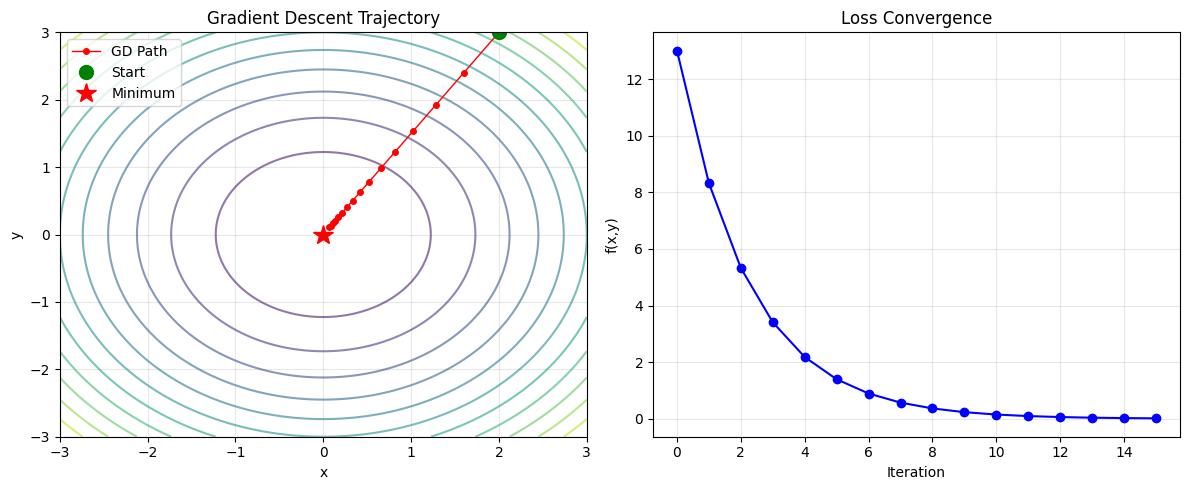


Converged to near (0, 0) -- the global minimum!


In [16]:
# Gradient Descent Implementation

def gradient_descent_2d(f_func, grad_func, x0, y0, lr=0.1, max_iter=20):
    """
    Perform gradient descent on a 2D function.

    Parameters:
    -----------
    f_func : callable
        Function f(x, y)
    grad_func : callable
        Function that returns gradient [df/dx, df/dy] at (x, y)
    x0, y0 : float
        Initial point
    lr : float
        Learning rate (alpha)
    max_iter : int
        Maximum number of iterations
    """
    history = []
    x, y = x0, y0

    for i in range(max_iter + 1):
        f_val = f_func(x, y)
        grad = grad_func(x, y)
        history.append({
            'Iteration': i,
            'x': x,
            'y': y,
            'f(x,y)': f_val,
            'df/dx': grad[0],
            'df/dy': grad[1],
            '||grad||': np.linalg.norm(grad)
        })

        # Gradient descent update
        x = x - lr * grad[0]
        y = y - lr * grad[1]

    return pd.DataFrame(history)

# Define gradient function for f(x,y) = x^2 + y^2
def grad_f(x, y):
    return np.array([2*x, 2*y])

# Run gradient descent
result_df = gradient_descent_2d(f, grad_f, x0=2.0, y0=3.0, lr=0.1, max_iter=15)

print("Gradient Descent: f(x,y) = x^2 + y^2")
print("Initial point: (2, 3), Learning rate: 0.1")
print("=" * 80)
print(result_df.to_string(index=False))

# Visualize convergence
plt.figure(figsize=(12, 5))

# Plot 1: Trajectory on contour plot
plt.subplot(1, 2, 1)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2
plt.contour(X, Y, Z, levels=15, cmap='viridis', alpha=0.6)
plt.plot(result_df['x'], result_df['y'], 'ro-', markersize=4, linewidth=1, label='GD Path')
plt.plot(result_df['x'].iloc[0], result_df['y'].iloc[0], 'go', markersize=10, label='Start')
plt.plot(0, 0, 'r*', markersize=15, label='Minimum')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss over iterations
plt.subplot(1, 2, 2)
plt.plot(result_df['Iteration'], result_df['f(x,y)'], 'b-o', markersize=6)
plt.xlabel('Iteration')
plt.ylabel('f(x,y)')
plt.title('Loss Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConverged to near (0, 0) -- the global minimum!")


## Section 16: Machine Learning Loss Function

### Concept Explanation

In machine learning, we define a **loss function** $L(w, b)$ that measures how wrong our predictions are.

For a simple linear model $\hat{y} = wx + b$ with one data point $(x, y) = (2, 5)$:

$$L(w, b) = (y - \hat{y})^2 = (5 - (2w + b))^2$$

### Partial Derivatives of Loss

$$\frac{\partial L}{\partial w} = -2x(y - \hat{y}) = -2(2)(5 - 2w - b)$$

$$\frac{\partial L}{\partial b} = -2(y - \hat{y}) = -2(5 - 2w - b)$$

### Interpretation

- $\frac{\partial L}{\partial w}$ tells us how to adjust the weight
- $\frac{\partial L}{\partial b}$ tells us how to adjust the bias
- Both derivatives point toward reducing the loss

### AI/ML Connection

This is the **mathematical foundation** of how neural networks learn. Every training step computes these derivatives for all parameters.


In [17]:
# Machine Learning Loss Function Analysis

# Define symbolic variables for ML parameters
w, b = symbols('w b', real=True)

# Simple linear model: y_hat = w*x + b
# Data point: x = 2, y = 5
x_data = 2
y_data = 5

# Loss function: L(w,b) = (y - y_hat)^2 = (5 - (2w + b))^2
L = (y_data - (w * x_data + b))**2

print("Machine Learning Setup:")
print(f"  Data point: (x, y) = ({x_data}, {y_data})")
print(f"  Model: y_hat = wx + b = 2w + b")
print(f"  Loss: L(w,b) = (y - y_hat)^2 = (5 - 2w - b)^2")
print()

# Compute partial derivatives
dL_dw = diff(L, w)
dL_db = diff(L, b)

print("Partial Derivatives of Loss:")
print(f"  dL/dw = {dL_dw}")
print(f"  dL/db = {dL_db}")
print()

# Simplify
dL_dw_simplified = simplify(dL_dw)
dL_db_simplified = simplify(dL_db)

print("Simplified:")
print(f"  dL/dw = {dL_dw_simplified}")
print(f"  dL/db = {dL_db_simplified}")
print()

# Evaluate at specific parameter values
param_values = [(0, 0), (1, 1), (2, 1), (2.5, 0)]

print("Loss and Gradients at Different Parameter Values:")
print("=" * 70)
print(f"{'(w, b)':<12} {'L(w,b)':<12} {'dL/dw':<12} {'dL/db':<12} {'||grad||':<12}")
print("-" * 70)

for w_val, b_val in param_values:
    L_val = L.subs([(w, w_val), (b, b_val)])
    dw_val = dL_dw_simplified.subs([(w, w_val), (b, b_val)])
    db_val = dL_db_simplified.subs([(w, w_val), (b, b_val)])
    grad_mag = float(np.sqrt(float(dw_val)**2 + float(db_val)**2))
    print(f"({w_val}, {b_val}){ '':<5} {float(L_val):<12.4f} {float(dw_val):<12.4f} {float(db_val):<12.4f} {grad_mag:<12.4f}")

# Find optimal parameters
print("\n" + "=" * 70)
print("Finding Optimal Parameters (Set grad = 0):")
optimal = solve([dL_dw, dL_db], [w, b])
print(f"  Optimal: {optimal}")
print(f"  This gives the line passing through (2, 5): y_hat = 2.5x + 0")


Machine Learning Setup:
  Data point: (x, y) = (2, 5)
  Model: y_hat = wx + b = 2w + b
  Loss: L(w,b) = (y - y_hat)^2 = (5 - 2w - b)^2

Partial Derivatives of Loss:
  dL/dw = 4*b + 8*w - 20
  dL/db = 2*b + 4*w - 10

Simplified:
  dL/dw = 4*b + 8*w - 20
  dL/db = 2*b + 4*w - 10

Loss and Gradients at Different Parameter Values:
(w, b)       L(w,b)       dL/dw        dL/db        ||grad||    
----------------------------------------------------------------------
(0, 0)      25.0000      -20.0000     -10.0000     22.3607     
(1, 1)      4.0000       -8.0000      -4.0000      8.9443      
(2, 1)      0.0000       0.0000       0.0000       0.0000      
(2.5, 0)      0.0000       0.0000       0.0000       0.0000      

Finding Optimal Parameters (Set grad = 0):
  Optimal: {w: 5/2 - b/2}
  This gives the line passing through (2, 5): y_hat = 2.5x + 0


## Section 17: Neural Network Gradient Computation

### Concept Explanation

A simple **neuron** computes:

$$\hat{y} = wx + b$$

With **Mean Squared Error (MSE)** loss for a single data point:

$$L = (y - \hat{y})^2 = (y - (wx + b))^2$$

### Backpropagation Intuition

Backpropagation is just the **chain rule** applied repeatedly:

1. Compute loss at output
2. Compute gradient of loss w.r.t. output
3. Propagate backward through each layer
4. Update weights using gradients

### Gradient Formulas

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial w} = -2(y - \hat{y}) \cdot x$$

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial b} = -2(y - \hat{y}) \cdot 1$$

### AI/ML Connection

This is the **entire basis of backpropagation**. In deep networks, we apply this chain rule through dozens or hundreds of layers.


In [18]:
# Neural Network Gradient Computation

print("=" * 60)
print("Neural Network: Single Neuron with MSE Loss")
print("=" * 60)

# Define symbolic variables
w_nn, b_nn, x_nn, y_true = symbols('w b x y_true', real=True)

# Forward pass
y_pred = w_nn * x_nn + b_nn
print(f"\nForward Pass:")
print(f"  y_hat = wx + b = {y_pred}")

# Loss function (MSE for single sample)
loss = (y_true - y_pred)**2
print(f"\nLoss Function (MSE):")
print(f"  L = (y_true - y_hat)^2 = {sp.expand(loss)}")

# Backward pass - compute gradients
dL_dw = diff(loss, w_nn)
dL_db = diff(loss, b_nn)
dL_dx = diff(loss, x_nn)  # Input gradient (for backprop to previous layer)

print(f"\nBackward Pass (Gradients):")
print(f"  dL/dw = {simplify(dL_dw)}")
print(f"  dL/db = {simplify(dL_db)}")
print(f"  dL/dx = {simplify(dL_dx)}  (gradient flowing to previous layer)")

# Numerical example
print("\n" + "=" * 60)
print("Numerical Example: x = 3, y_true = 10, w = 2, b = 1")
print("=" * 60)

x_val, y_val, w_val, b_val = 3, 10, 2, 1
y_pred_val = w_val * x_val + b_val
loss_val = (y_val - y_pred_val)**2

dL_dw_val = float(dL_dw.subs([(w_nn, w_val), (b_nn, b_val), (x_nn, x_val), (y_true, y_val)]))
dL_db_val = float(dL_db.subs([(w_nn, w_val), (b_nn, b_val), (x_nn, x_val), (y_true, y_val)]))

print(f"  Forward: y_hat = {w_val}x{x_val} + {b_val} = {y_pred_val}")
print(f"  Loss: L = ({y_val} - {y_pred_val})^2 = {loss_val}")
print(f"  dL/dw = {dL_dw_val}")
print(f"  dL/db = {dL_db_val}")

# Weight update with learning rate 0.01
lr = 0.01
w_new = w_val - lr * dL_dw_val
b_new = b_val - lr * dL_db_val

print(f"\n  Weight Update (lr = {lr}):")
print(f"  w_new = {w_val} - {lr} x {dL_dw_val} = {w_new:.4f}")
print(f"  b_new = {b_val} - {lr} x {dL_db_val} = {b_new:.4f}")

# Verify loss decreased
loss_new = (y_val - (w_new * x_val + b_new))**2
print(f"\n  Loss before: {loss_val}")
print(f"  Loss after:  {loss_new:.4f}")
print(f"  Loss decreased: {loss_val > loss_new}")


Neural Network: Single Neuron with MSE Loss

Forward Pass:
  y_hat = wx + b = b + w*x

Loss Function (MSE):
  L = (y_true - y_hat)^2 = b**2 + 2*b*w*x - 2*b*y_true + w**2*x**2 - 2*w*x*y_true + y_true**2

Backward Pass (Gradients):
  dL/dw = 2*x*(b + w*x - y_true)
  dL/db = 2*b + 2*w*x - 2*y_true
  dL/dx = 2*w*(b + w*x - y_true)  (gradient flowing to previous layer)

Numerical Example: x = 3, y_true = 10, w = 2, b = 1
  Forward: y_hat = 2x3 + 1 = 7
  Loss: L = (10 - 7)^2 = 9
  dL/dw = -18.0
  dL/db = -6.0

  Weight Update (lr = 0.01):
  w_new = 2 - 0.01 x -18.0 = 2.1800
  b_new = 1 - 0.01 x -6.0 = 1.0600

  Loss before: 9
  Loss after:  5.7600
  Loss decreased: True


In [19]:
from sympy import expand

# Chain rule visualization for multi-layer intuition
print("=" * 60)
print("Chain Rule Visualization (Backpropagation Intuition)")
print("=" * 60)

# Layer 1: z = wx + b
# Layer 2: a = sigmoid(z)  [simplified as activation]
# Layer 3: L = (y - a)^2

z = symbols('z')
# Using a simple activation for demonstration: a = z (linear for simplicity)
a = z  # In reality: a = 1/(1+exp(-z))

# Chain rule: dL/dw = dL/da * da/dz * dz/dw
dL_da = diff((y_true - a)**2, a)
da_dz = diff(a, z)
dz_dw = diff(w_nn * x_nn + b_nn, w_nn)

print(f"\nChain Rule Breakdown:")
print(f"  dL/da = {dL_da}")
print(f"  da/dz = {da_dz}")
print(f"  dz/dw = {dz_dw}")
print(f"\n  dL/dw = dL/da x da/dz x dz/dw = {simplify(dL_da * da_dz * dz_dw)}")
print(f"\n  This matches our direct computation: {simplify(dL_dw)}")
print(f"\n  Chain rule verified!")

print("\n" + "=" * 60)
print("Key Insight: Backpropagation is just repeated application")
print("of the chain rule through the computational graph.")
print("=" * 60)


Chain Rule Visualization (Backpropagation Intuition)

Chain Rule Breakdown:
  dL/da = -2*y_true + 2*z
  da/dz = 1
  dz/dw = x

  dL/dw = dL/da x da/dz x dz/dw = 2*x*(-y_true + z)

  This matches our direct computation: 2*x*(b + w*x - y_true)

  Chain rule verified!

Key Insight: Backpropagation is just repeated application
of the chain rule through the computational graph.


## Section 18: Mini Project

### Objective

Optimize the function:

$$f(x, y) = x^2 + 2y^2 + 3$$

Using **Gradient Descent** from a chosen initial point.

### Analysis

- $\frac{\partial f}{\partial x} = 2x$
- $\frac{\partial f}{\partial y} = 4y$
- Critical point: $(0, 0)$
- Minimum value: $f(0, 0) = 3$

Notice that the function is **steeper in the y-direction** (coefficient 2 for $y^2$), so the gradient has different scales.

### Tasks

1. Implement gradient descent
2. Track convergence history
3. Visualize the optimization path
4. Analyze the effect of learning rate


In [20]:
# Mini Project: Optimize f(x,y) = x^2 + 2y^2 + 3

def f_project(x, y):
    """Target function: f(x,y) = x^2 + 2y^2 + 3"""
    return x**2 + 2*y**2 + 3

def grad_project(x, y):
    """Gradient: [df/dx, df/dy] = [2x, 4y]"""
    return np.array([2*x, 4*y])

# Gradient descent with detailed tracking
def gradient_descent_project(x0, y0, lr=0.1, max_iter=30, tolerance=1e-6):
    history = []
    x, y = x0, y0

    for i in range(max_iter + 1):
        f_val = f_project(x, y)
        grad = grad_project(x, y)
        grad_mag = np.linalg.norm(grad)

        history.append({
            'Iteration': i,
            'x': round(x, 6),
            'y': round(y, 6),
            'f(x,y)': round(f_val, 6),
            '||grad||': round(grad_mag, 6)
        })

        # Check convergence
        if grad_mag < tolerance:
            print(f"Converged at iteration {i}")
            break

        # Update
        x = x - lr * grad[0]
        y = y - lr * grad[1]

    return pd.DataFrame(history), (x, y)

# Run optimization
print("=" * 60)
print("Mini Project: Optimize f(x,y) = x^2 + 2y^2 + 3")
print("=" * 60)
print(f"Initial point: (3, 2)")
print(f"Learning rate: 0.1")
print(f"Maximum iterations: 30")
print()

history_df, final_point = gradient_descent_project(3.0, 2.0, lr=0.1, max_iter=30)

print("Convergence History:")
print(history_df.to_string(index=False))

print(f"\n" + "=" * 60)
print("Results:")
print(f"  Initial point: (3, 2)")
print(f"  Final point: ({final_point[0]:.6f}, {final_point[1]:.6f})")
print(f"  Final minimum: f({final_point[0]:.6f}, {final_point[1]:.6f}) = {f_project(final_point[0], final_point[1]):.6f}")
print(f"  Theoretical minimum: f(0, 0) = 3")
print(f"  Error: {abs(f_project(final_point[0], final_point[1]) - 3):.8f}")


Mini Project: Optimize f(x,y) = x^2 + 2y^2 + 3
Initial point: (3, 2)
Learning rate: 0.1
Maximum iterations: 30

Convergence History:
 Iteration        x        y    f(x,y)  ||grad||
         0 3.000000 2.000000 20.000000 10.000000
         1 2.400000 1.200000 11.640000  6.788225
         2 1.920000 0.720000  7.723200  4.800000
         3 1.536000 0.432000  5.732544  3.524651
         4 1.228800 0.259200  4.644319  2.667349
         5 0.983040 0.155520  4.014741  2.062148
         6 0.786432 0.093312  3.635890  1.616544
         7 0.629146 0.055987  3.402093  1.278065
         8 0.503316 0.033592  3.255584  1.015561
         9 0.402653 0.020155  3.162942  0.809332
        10 0.322123 0.012093  3.104055  0.646059
        11 0.257698 0.007256  3.066514  0.516213
        12 0.206158 0.004354  3.042539  0.412684
        13 0.164927 0.002612  3.027214  0.330019
        14 0.131941 0.001567  3.017413  0.263957
        15 0.105553 0.000940  3.011143  0.211140
        16 0.084442 0.000564  3.00

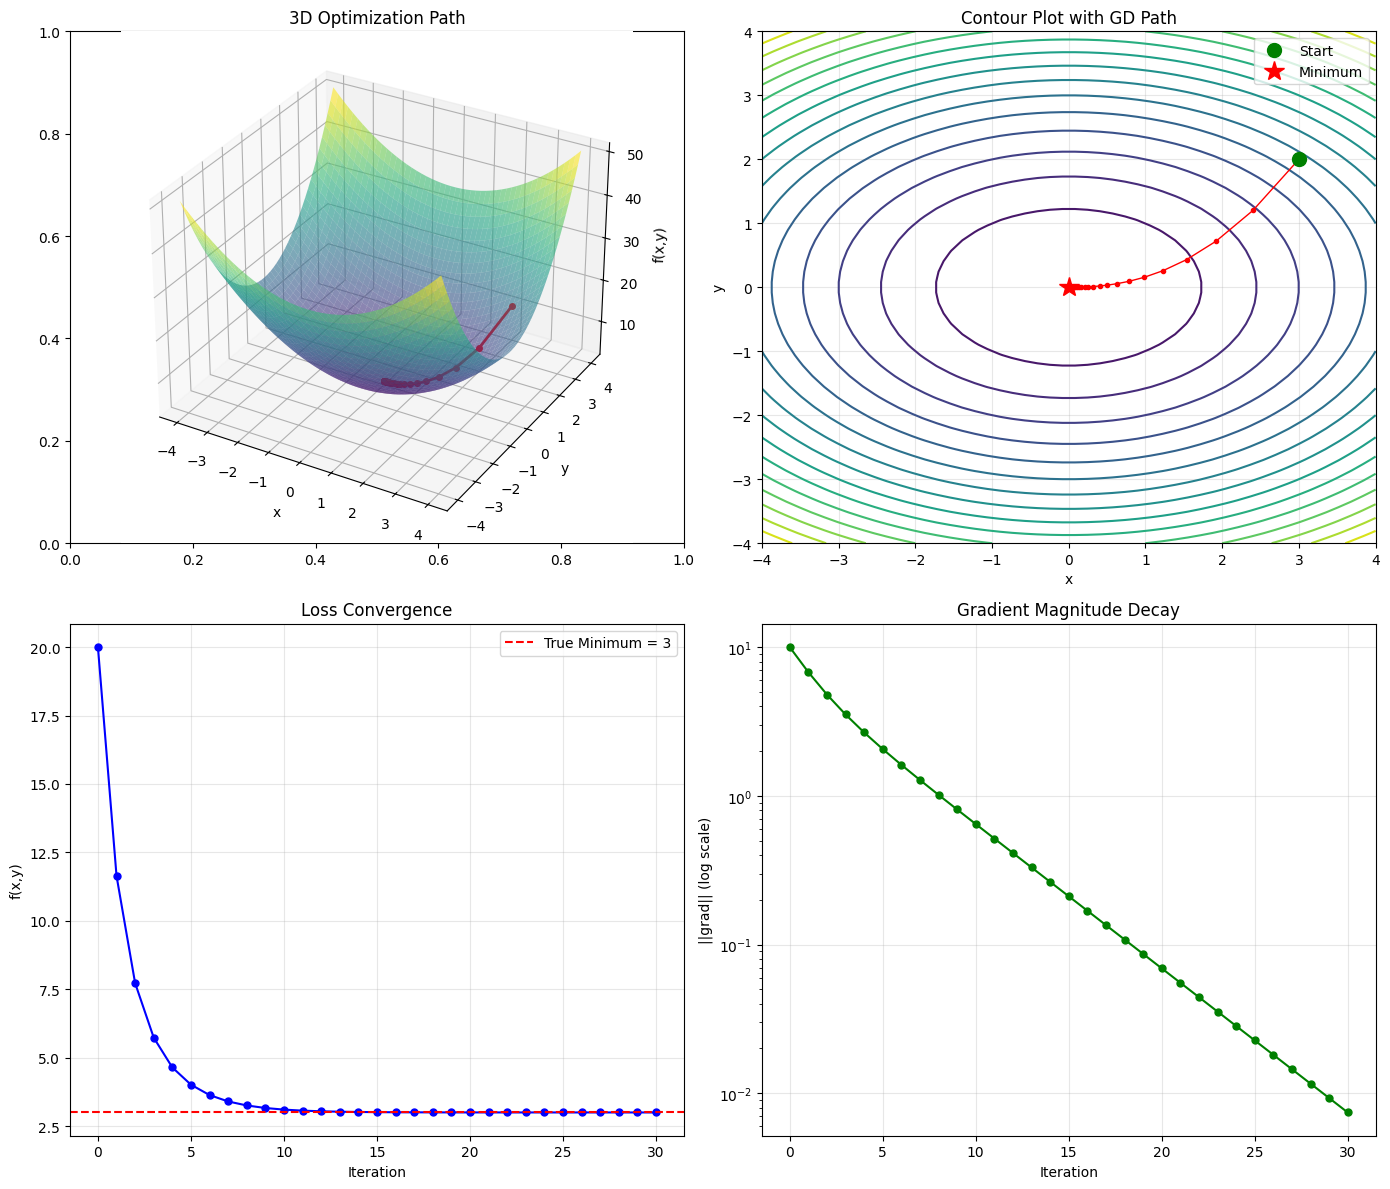


Analysis:
   - The function converges smoothly to the global minimum
   - Gradient magnitude decays exponentially (linear on log scale)
   - The path is more compressed in y-direction due to steeper curvature


In [21]:
# Visualize the mini project results

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: 3D Surface with optimization path
ax1 = axes[0, 0]
x = np.linspace(-4, 4, 50)
y = np.linspace(-4, 4, 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + 2*Y**2 + 3

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
ax1.plot(history_df['x'], history_df['y'], history_df['f(x,y)'], 
         'r-o', markersize=4, linewidth=2, label='GD Path')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Optimization Path')

# Plot 2: Contour with path
ax2 = axes[0, 1]
contour = ax2.contour(X, Y, Z, levels=15, cmap='viridis')
ax2.plot(history_df['x'], history_df['y'], 'ro-', markersize=3, linewidth=1)
ax2.plot(history_df['x'].iloc[0], history_df['y'].iloc[0], 'go', markersize=10, label='Start')
ax2.plot(0, 0, 'r*', markersize=15, label='Minimum')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot with GD Path')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Loss convergence
ax3 = axes[1, 0]
ax3.plot(history_df['Iteration'], history_df['f(x,y)'], 'b-o', markersize=5)
ax3.axhline(y=3, color='r', linestyle='--', label='True Minimum = 3')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('f(x,y)')
ax3.set_title('Loss Convergence')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Gradient magnitude decay
ax4 = axes[1, 1]
ax4.semilogy(history_df['Iteration'], history_df['||grad||'], 'g-o', markersize=5)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('||grad|| (log scale)')
ax4.set_title('Gradient Magnitude Decay')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalysis:")
print("   - The function converges smoothly to the global minimum")
print("   - Gradient magnitude decays exponentially (linear on log scale)")
print("   - The path is more compressed in y-direction due to steeper curvature")


## Section 19: AI Applications

### How Partial Derivatives Power Modern AI

Partial derivatives are not just mathematical concepts -- they are the **computational engine** behind virtually all modern AI systems.

---

### 1. Gradient Descent & Stochastic Gradient Descent (SGD)

Every weight update:

$$w_{t+1} = w_t - \alpha \nabla_w L$$

Partial derivatives tell us **which direction** to move each parameter to reduce loss.

---

### 2. Neural Networks & Backpropagation

Backpropagation applies the **chain rule** through layers:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a_n} \cdot \frac{\partial a_n}{\partial z_n} \cdot \frac{\partial z_n}{\partial a_{n-1}} \cdots \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1}$$

Without partial derivatives, deep networks could not be trained.

---

### 3. Convolutional Neural Networks (CNNs)

In CNNs, partial derivatives flow through:
- Convolutional layers (weight sharing)
- Pooling layers (gradient routing)
- Activation functions (element-wise derivatives)

**Application:** Image classification, object detection, medical imaging

---

### 4. Recurrent Neural Networks (RNNs)

For sequential data, partial derivatives are computed **through time** (BPTT -- Backpropagation Through Time):

$$\frac{\partial L}{\partial W} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W}$$

**Application:** Time series prediction, natural language processing, speech recognition

---

### 5. Transformers & Large Language Models (LLMs)

Modern LLMs (GPT, BERT, Claude) have **billions of parameters**. Training involves computing partial derivatives for:
- Attention weights
- Feed-forward layer weights
- Embedding matrices
- Layer normalization parameters

**Scale:** GPT-4 has ~1.8 trillion parameters. Each training step computes ~1.8 trillion partial derivatives.

---

### 6. Reinforcement Learning

Policy gradient methods directly optimize policies using partial derivatives:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot R_t\right]$$

**Application:** Game playing (AlphaGo, AlphaZero), robotics, autonomous driving

---

### 7. Computer Vision -- Edge Detection

The Sobel operator uses partial derivatives to detect edges:

$$G_x = \frac{\partial I}{\partial x}, \quad G_y = \frac{\partial I}{\partial y}$$

$$\text{Edge magnitude} = \sqrt{G_x^2 + G_y^2}$$

---

### 8. Generative AI & Normalizing Flows

Normalizing flows use the **Jacobian determinant** to transform probability distributions:

$$p_x(x) = p_z(f(x)) \left| \det \frac{\partial f}{\partial x} \right|$$

**Application:** Image generation, density estimation, variational inference

---

### Practical Example: Training a Neural Network

```python
# PyTorch automatically computes partial derivatives!
import torch

x = torch.tensor([2.0], requires_grad=True)
y = x ** 2 + 3 * x + 1
y.backward()  # Computes all partial derivatives
print(x.grad)  # dy/dx = 2*2 + 3 = 7
```

This single `.backward()` call computes **millions of partial derivatives** in a large network.


In [22]:
# Demonstration: PyTorch-style automatic differentiation concept

print("=" * 60)
print("Automatic Differentiation (Autograd) Concept")
print("=" * 60)

# Simulate a simple computation graph
# z = x^2 + y^2, where x = 3, y = 4
# We want dz/dx and dz/dy

x_val = 3.0
y_val = 4.0

# Forward pass
z_val = x_val**2 + y_val**2

print(f"Forward Pass:")
print(f"  x = {x_val}, y = {y_val}")
print(f"  z = x^2 + y^2 = {z_val}")

# Backward pass (manual chain rule)
dz_dx = 2 * x_val  # dz/dx
dz_dy = 2 * y_val  # dz/dy

print(f"\nBackward Pass (Partial Derivatives):")
print(f"  dz/dx = 2x = {dz_dx}")
print(f"  dz/dy = 2y = {dz_dy}")

# Simulate gradient descent step
lr = 0.01
x_new = x_val - lr * dz_dx
y_new = y_val - lr * dz_dy
z_new = x_new**2 + y_new**2

print(f"\nGradient Descent Step (lr = {lr}):")
print(f"  x_new = {x_val} - {lr} x {dz_dx} = {x_new}")
print(f"  y_new = {y_val} - {lr} x {dz_dy} = {y_new}")
print(f"  z_new = {z_new:.4f} (decreased from {z_val})")

print("\n" + "=" * 60)
print("This is exactly what PyTorch, TensorFlow, and JAX do,")
print("but automatically for millions of parameters!")
print("=" * 60)

# Scale comparison
print(f"\nScale Comparison:")
print(f"  Small NN (LeNet, 1989):     ~60,000 parameters")
print(f"  ResNet-50 (2015):            ~25,000,000 parameters")
print(f"  GPT-3 (2020):                ~175,000,000,000 parameters")
print(f"  GPT-4 (2023):                ~1,800,000,000,000 parameters")
print(f"\n  Each training step computes partial derivatives for ALL parameters!")


Automatic Differentiation (Autograd) Concept
Forward Pass:
  x = 3.0, y = 4.0
  z = x^2 + y^2 = 25.0

Backward Pass (Partial Derivatives):
  dz/dx = 2x = 6.0
  dz/dy = 2y = 8.0

Gradient Descent Step (lr = 0.01):
  x_new = 3.0 - 0.01 x 6.0 = 2.94
  y_new = 4.0 - 0.01 x 8.0 = 3.92
  z_new = 24.0100 (decreased from 25.0)

This is exactly what PyTorch, TensorFlow, and JAX do,
but automatically for millions of parameters!

Scale Comparison:
  Small NN (LeNet, 1989):     ~60,000 parameters
  ResNet-50 (2015):            ~25,000,000 parameters
  GPT-3 (2020):                ~175,000,000,000 parameters
  GPT-4 (2023):                ~1,800,000,000,000 parameters

  Each training step computes partial derivatives for ALL parameters!


## Section 20: Summary

### Complete Review of Partial Derivatives

We have covered the complete foundation of multivariable calculus for Machine Learning and AI.

---

### Key Concepts Mastered

| Topic | Description | ML/AI Application |
|-------|-------------|-------------------|
| **Partial Derivatives** | Rate of change w.r.t. one variable | Weight updates in gradient descent |
| **Gradient Vector** | Collection of all partial derivatives | Direction of steepest ascent |
| **Directional Derivatives** | Rate of change in any direction | Line search, sensitivity analysis |
| **Jacobian Matrix** | Derivatives of vector-valued functions | Backpropagation, normalizing flows |
| **Hessian Matrix** | Second-order derivative matrix | Second-order optimization, curvature |
| **Critical Points** | Where gradient is zero | Finding minima in loss landscapes |
| **Optimization** | Finding minima/maxima | Training neural networks |
| **Gradient Descent** | Iterative minimization algorithm | Standard training procedure |
| **Backpropagation** | Chain rule applied to neural networks | Computing gradients in deep networks |

---

### Key Takeaways

1. **Partial derivatives** measure how a function changes when one variable changes
2. The **gradient** points in the direction of steepest increase
3. **Gradient descent** moves in the negative gradient direction to minimize functions
4. The **Hessian** reveals curvature and helps classify critical points
5. **Backpropagation** is just the chain rule applied systematically through a computational graph
6. **Every AI system** relies on these concepts -- from simple linear regression to GPT-4

---

### What's Next?

- **Multivariable Chain Rule** -- Essential for understanding backpropagation deeply
- **Lagrange Multipliers** -- Constrained optimization in ML
- **Probability & Statistics** -- Foundation for generative models
- **Linear Algebra** -- Matrix operations in neural networks
- **Differential Equations** -- Neural ODEs, continuous-depth networks

---

### References

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
- Strang, G. (2019). *Linear Algebra and Learning from Data*. Wellesley-Cambridge Press.

---

**Created for:** MLVerse-Math  
**Topic:** 05_Partial_Derivatives  
**Libraries:** NumPy, SymPy, Pandas, Matplotlib

> *"The essence of calculus is the derivative. The essence of machine learning is the partial derivative."*


In [23]:
# Final verification: All libraries working
print("=" * 60)
print("Notebook Complete!")
print("=" * 60)
print(f"NumPy version: {np.__version__}")
print(f"SymPy version: {sp.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print("=" * 60)
print("All sections completed successfully!")
print("Topics covered: Multivariable functions, Partial derivatives,")
print("Gradient vectors, Hessian, Jacobian, Gradient Descent,")
print("Backpropagation, and AI Applications.")


Notebook Complete!
NumPy version: 2.4.6
SymPy version: 1.14.0
Pandas version: 3.0.3
Matplotlib version: 3.10.9
All sections completed successfully!
Topics covered: Multivariable functions, Partial derivatives,
Gradient vectors, Hessian, Jacobian, Gradient Descent,
Backpropagation, and AI Applications.
